In [1]:
!pip install imbalanced-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (classification_report, f1_score, accuracy_score,
                              confusion_matrix, mean_squared_error, cohen_kappa_score,
                              precision_score, recall_score)
from imblearn.over_sampling import SMOTE

In [2]:
from google.colab import files
uploaded = files.upload()  # choose growth_tracker_combined_v4.csv

df = pd.read_csv("nutritrack.csv")

# NOTE: no "tall" drop here anymore -- Tall is now a real, populated class
print(df.shape)
df.head()

Saving nutritrack.csv to nutritrack.csv
(226, 9)


,Age_in_Months,Sex,Weight_kg,Height_cm,Vaccinated,4ps_Beneficiary,BMI,HFA,Is_Synthetic
0,6.0,Female,6.2,65.1,yes,yes,Normal,Normal,No
1,21.0,Female,8.9,78.0,no,no,Normal,Normal,No
2,42.0,Male,12.1,95.0,yes,yes,Normal,Normal,No
3,58.0,Female,17.2,102.6,no,no,Normal,Normal,No
4,39.0,Male,11.0,88.0,yes,yes,Normal,Stunted,No


In [3]:
df_enc = df.copy()

le_sex = LabelEncoder()
le_vax = LabelEncoder()
le_4ps = LabelEncoder()

df_enc["Sex"] = le_sex.fit_transform(df_enc["Sex"].astype(str))
df_enc["Vaccinated"] = le_vax.fit_transform(df_enc["Vaccinated"].astype(str))
df_enc["4ps_Beneficiary"] = le_4ps.fit_transform(df_enc["4ps_Beneficiary"].astype(str))

feature_cols = ["Age_in_Months", "Sex", "Weight_kg", "Height_cm", "Vaccinated", "4ps_Beneficiary"]
X = df_enc[feature_cols]

In [4]:
def run_target(X, y, target_name):
    le_target = LabelEncoder()
    y_enc = le_target.fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    min_class_count = pd.Series(y_train).value_counts().min()
    k_neighbors = max(1, min(5, min_class_count - 1))
    smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
    X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

    models = {
        "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
        "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
        "DecisionTree": DecisionTreeClassifier(random_state=42),
    }

    results = {}
    for name, model in models.items():
        model.fit(X_train_res, y_train_res)
        preds = model.predict(X_test_scaled)
        acc = accuracy_score(y_test, preds)
        f1_macro = f1_score(y_test, preds, average="macro")
        results[name] = {"model": model, "accuracy": acc, "f1_macro": f1_macro,
                          "y_test": y_test, "preds": preds}
        print(f"--- {target_name} | {name} ---")
        print(f"Accuracy: {acc:.3f} | Macro F1: {f1_macro:.3f}")
        print(classification_report(y_test, preds, target_names=le_target.classes_))
        print()

    best_name = max(results, key=lambda k: results[k]["f1_macro"])
    print(f"Best model for {target_name}: {best_name} (Macro F1 = {results[best_name]['f1_macro']:.3f})")
    return results[best_name]["model"], le_target, results, best_name, scaler

In [5]:
y_bmi = df_enc["BMI"]
best_bmi_model, le_bmi, bmi_results, best_bmi_name, scaler_bmi = run_target(X, y_bmi, "BMI")

--- BMI | RandomForest ---
Accuracy: 0.630 | Macro F1: 0.521
                 precision    recall  f1-score   support

         Normal       0.78      0.72      0.75        29
          Obese       1.00      0.75      0.86         4
     Overweight       0.50      0.50      0.50         4
Severely Wasted       0.43      0.60      0.50         5
         Wasted       0.00      0.00      0.00         4

       accuracy                           0.63        46
      macro avg       0.54      0.51      0.52        46
   weighted avg       0.67      0.63      0.65        46


--- BMI | LogisticRegression ---
Accuracy: 0.587 | Macro F1: 0.526
                 precision    recall  f1-score   support

         Normal       0.89      0.59      0.71        29
          Obese       0.75      0.75      0.75         4
     Overweight       0.33      0.50      0.40         4
Severely Wasted       0.50      0.80      0.62         5
         Wasted       0.11      0.25      0.15         4

       accu

In [6]:
y_hfa = df_enc["HFA"]
best_hfa_model, le_hfa, hfa_results, best_hfa_name, scaler_hfa = run_target(X, y_hfa, "HFA")

--- HFA | RandomForest ---
Accuracy: 0.717 | Macro F1: 0.538
                  precision    recall  f1-score   support

          Normal       0.84      0.84      0.84        32
Severely Stunted       0.50      0.75      0.60         4
         Stunted       0.29      0.33      0.31         6
            Tall       1.00      0.25      0.40         4

        accuracy                           0.72        46
       macro avg       0.66      0.54      0.54        46
    weighted avg       0.75      0.72      0.71        46


--- HFA | LogisticRegression ---
Accuracy: 0.587 | Macro F1: 0.577
                  precision    recall  f1-score   support

          Normal       0.80      0.62      0.70        32
Severely Stunted       0.75      0.75      0.75         4
         Stunted       0.13      0.33      0.19         6
            Tall       1.00      0.50      0.67         4

        accuracy                           0.59        46
       macro avg       0.67      0.55      0.58       

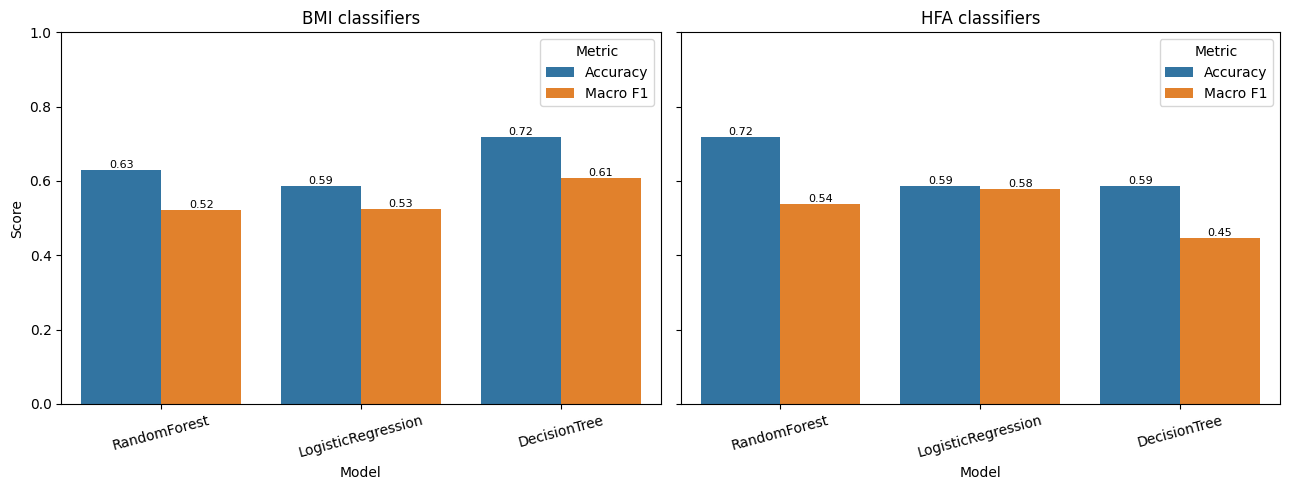

In [7]:
def build_comparison_df(results, target_name):
    return pd.DataFrame([
        {"Target": target_name, "Model": name, "Accuracy": r["accuracy"], "Macro F1": r["f1_macro"]}
        for name, r in results.items()
    ])

comp_df = pd.concat([
    build_comparison_df(bmi_results, "BMI"),
    build_comparison_df(hfa_results, "HFA"),
], ignore_index=True)

comp_melted = comp_df.melt(id_vars=["Target", "Model"], value_vars=["Accuracy", "Macro F1"],
                            var_name="Metric", value_name="Score")

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, target in zip(axes, ["BMI", "HFA"]):
    sub = comp_melted[comp_melted["Target"] == target]
    sns.barplot(data=sub, x="Model", y="Score", hue="Metric", ax=ax)
    ax.set_title(f"{target} classifiers")
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=15)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", fontsize=8)
plt.tight_layout()
plt.show()

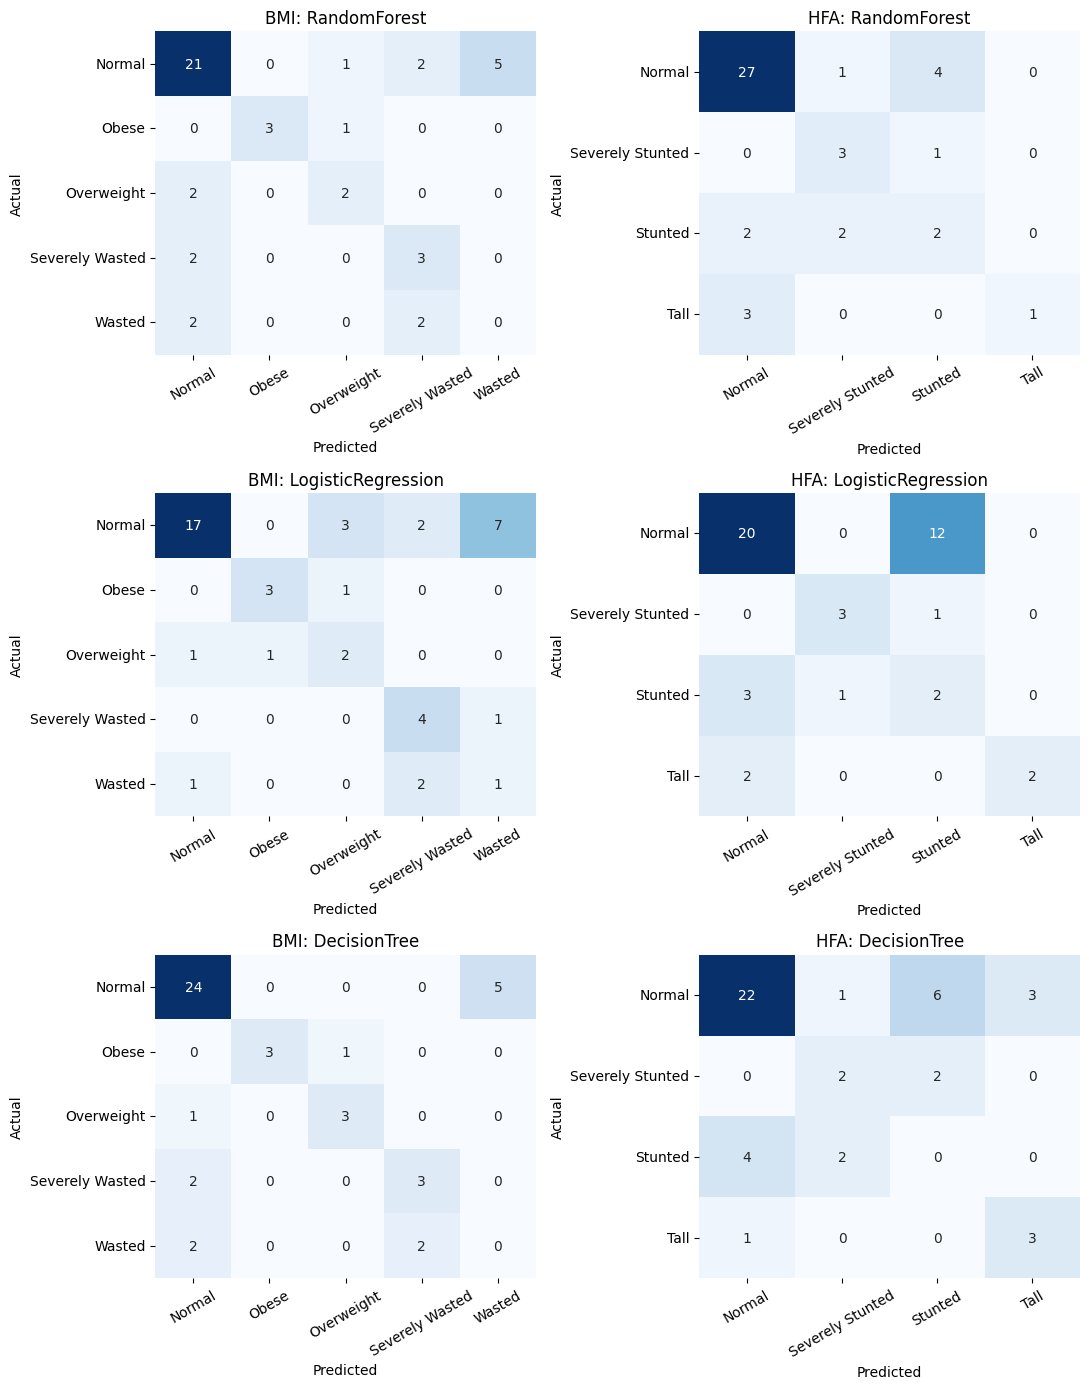

In [8]:
fig, axes = plt.subplots(3, 2, figsize=(11, 14))
for row, model_name in enumerate(["RandomForest", "LogisticRegression", "DecisionTree"]):
    for col, (target_name, results, le) in enumerate(
        [("BMI", bmi_results, le_bmi), ("HFA", hfa_results, le_hfa)]
    ):
        r = results[model_name]
        cm = confusion_matrix(r["y_test"], r["preds"])
        ax = axes[row, col]
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=le.classes_, yticklabels=le.classes_, ax=ax, cbar=False)
        ax.set_title(f"{target_name}: {model_name}")
        ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
        ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

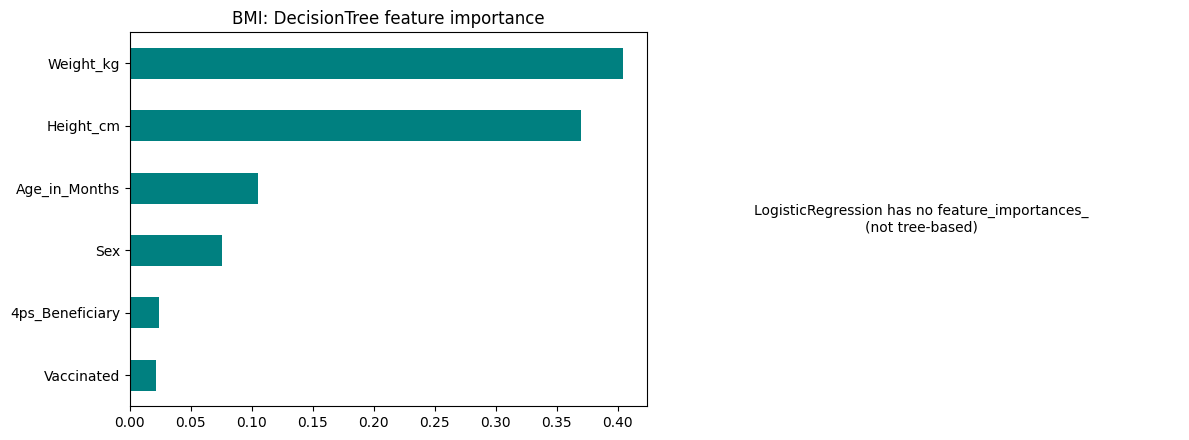

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (target_name, results, best_name) in zip(
    axes, [("BMI", bmi_results, best_bmi_name), ("HFA", hfa_results, best_hfa_name)]
):
    model = results[best_name]["model"]
    if hasattr(model, "feature_importances_"):
        pd.Series(model.feature_importances_, index=feature_cols).sort_values().plot(
            kind="barh", ax=ax, color="teal")
        ax.set_title(f"{target_name}: {best_name} feature importance")
    else:
        ax.axis("off")
        ax.text(0.5, 0.5, f"{best_name} has no feature_importances_\n(not tree-based)",
                ha="center", va="center")
plt.tight_layout()
plt.show()

In [10]:
# Classes are ordered by actual clinical severity (WHO z-score order),
# NOT alphabetically -- this is what makes RMSE/MSE meaningful here.
BMI_ORDER = {"Severely Wasted": 0, "Wasted": 1, "Normal": 2, "Overweight": 3, "Obese": 4}
HFA_ORDER = {"Severely Stunted": 0, "Stunted": 1, "Normal": 2, "Tall": 3}

def ordinal_metrics(results, le, order_map, target_name):
    rows = []
    for model_name, r in results.items():
        true_names = le.inverse_transform(r["y_test"])
        pred_names = le.inverse_transform(r["preds"])
        true_ord = [order_map[n] for n in true_names]
        pred_ord = [order_map[n] for n in pred_names]

        mse = mean_squared_error(true_ord, pred_ord)
        rmse = np.sqrt(mse)
        kappa = cohen_kappa_score(true_ord, pred_ord)
        weighted_kappa = cohen_kappa_score(true_ord, pred_ord, weights="quadratic")

        rows.append({"Target": target_name, "Model": model_name,
                      "RMSE (severity bands)": round(rmse, 3),
                      "MSE (severity bands)": round(mse, 3),
                      "Cohen's Kappa": round(kappa, 3),
                      "Weighted Kappa": round(weighted_kappa, 3)})
    return pd.DataFrame(rows)

ordinal_df = pd.concat([
    ordinal_metrics(bmi_results, le_bmi, BMI_ORDER, "BMI"),
    ordinal_metrics(hfa_results, le_hfa, HFA_ORDER, "HFA"),
], ignore_index=True)

print("RMSE/MSE here = average number of severity bands the prediction missed by")
print("(0 = perfect; 1.0 = typically off by one band, e.g. Normal predicted as Wasted)")
print("Kappa = agreement beyond random chance (0 = chance, 1 = perfect; >0.6 is considered good)\n")
ordinal_df

RMSE/MSE here = average number of severity bands the prediction missed by
(0 = perfect; 1.0 = typically off by one band, e.g. Normal predicted as Wasted)
Kappa = agreement beyond random chance (0 = chance, 1 = perfect; >0.6 is considered good)



,Target,Model,RMSE (severity bands),MSE (severity bands),Cohen's Kappa,Weighted Kappa
0,BMI,RandomForest,0.794,0.630,0.374,0.686
1,BMI,LogisticRegression,0.737,0.543,0.397,0.764
2,BMI,DecisionTree,0.643,0.413,0.502,0.775
3,HFA,RandomForest,0.590,0.348,0.415,0.681
4,HFA,LogisticRegression,0.643,0.413,0.273,0.619
5,HFA,DecisionTree,0.692,0.478,0.247,0.598


In [11]:
def full_summary(results, le, target_name):
    rows = []
    for model_name, r in results.items():
        rows.append({
            "Target": target_name, "Model": model_name,
            "Accuracy": round(r["accuracy"], 3),
            "Macro F1": round(r["f1_macro"], 3),
            "Weighted F1": round(f1_score(r["y_test"], r["preds"], average="weighted"), 3),
            "Macro Precision": round(precision_score(r["y_test"], r["preds"], average="macro", zero_division=0), 3),
            "Macro Recall": round(recall_score(r["y_test"], r["preds"], average="macro", zero_division=0), 3),
        })
    return pd.DataFrame(rows)

summary_df = pd.concat([
    full_summary(bmi_results, le_bmi, "BMI"),
    full_summary(hfa_results, le_hfa, "HFA"),
], ignore_index=True)

final_report = summary_df.merge(ordinal_df, on=["Target", "Model"])
final_report

,Target,Model,Accuracy,Macro F1,Weighted F1,Macro Precision,Macro Recall,RMSE (severity bands),MSE (severity bands),Cohen's Kappa,Weighted Kappa
0,BMI,RandomForest,0.630,0.521,0.645,0.541,0.515,0.794,0.630,0.374,0.686
1,BMI,LogisticRegression,0.587,0.526,0.627,0.518,0.577,0.737,0.543,0.397,0.764
2,BMI,DecisionTree,0.717,0.607,0.727,0.636,0.586,0.643,0.413,0.502,0.775
3,HFA,RandomForest,0.717,0.538,0.714,0.657,0.544,0.590,0.348,0.415,0.681
4,HFA,LogisticRegression,0.587,0.577,0.636,0.671,0.552,0.643,0.413,0.273,0.619
5,HFA,DecisionTree,0.587,0.448,0.610,0.429,0.484,0.692,0.478,0.247,0.598


In [12]:
import joblib

joblib.dump(best_bmi_model, "bmi_model.pkl")
joblib.dump(le_bmi, "bmi_label_encoder.pkl")
joblib.dump(scaler_bmi, "bmi_scaler.pkl")
joblib.dump(best_hfa_model, "hfa_model.pkl")
joblib.dump(le_hfa, "hfa_label_encoder.pkl")
joblib.dump(scaler_hfa, "hfa_scaler.pkl")
joblib.dump({"sex": le_sex, "vaccinated": le_vax, "4ps": le_4ps}, "feature_encoders.pkl")

for f in ["bmi_model.pkl", "bmi_label_encoder.pkl", "bmi_scaler.pkl",
          "hfa_model.pkl", "hfa_label_encoder.pkl", "hfa_scaler.pkl",
          "feature_encoders.pkl"]:
    files.download(f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>